# BPE and Tokenization assignment

This notebook demonstrates:
- Applying BPE on text in English, French, Spanish, and German.
- Computing compression ratios for each language using BPE.
- Computing compression ratios using the GPT tiktoken library and comparing
- Computing the effect of vocabulary size on compression ratio for English, French, Spanish and German.
- Analyzing the effect of file size on the compression ratio for English text.



In [ ]:
# Install necessary packages
!pip install tiktoken matplotlib -q

import re
import collections
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# BPE helper functions (as discussed in class)
# ─────────────────────────────────────────────

def get_vocab(text):
    """Build initial word-level vocabulary with character-split representation."""
    vocab = collections.defaultdict(int)
    for word in text.strip().split():
        vocab[' '.join(list(word)) + ' </w>'] += 1
    return vocab

def get_stats(vocab):
    """Count frequency of each adjacent pair of symbols."""
    pairs = collections.defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs

def merge_vocab(pair, v_in):
    """Merge the most frequent pair in the vocabulary."""
    v_out = {}
    bigram = re.escape(' '.join(pair))
    p = re.compile(r'(?<' + r'!\S)' + bigram + r'(?!\S)')
    for word in v_in:
        w_out = p.sub(''.join(pair), word)
        v_out[w_out] = v_in[word]
    return v_out

def get_tokens_from_vocab(vocab):
    """Extract all tokens from the current vocabulary."""
    tokens = collections.defaultdict(int)
    for word, freq in vocab.items():
        word_tokens = word.split()
        for token in word_tokens:
            tokens[token] += freq
    return tokens

def run_bpe(text, num_merges):
    """
    Run BPE on text for num_merges merge operations.
    Returns the final vocab and the number of tokens in the encoded text.
    """
    vocab = get_vocab(text)
    for i in range(num_merges):
        pairs = get_stats(vocab)
        if not pairs:
            break
        best = max(pairs, key=pairs.get)
        vocab = merge_vocab(best, vocab)
    tokens = get_tokens_from_vocab(vocab)
    return vocab, tokens

def compute_compression_ratio(text, num_merges):
    """
    Compute BPE compression ratio:
      ratio = (original number of characters) / (number of tokens after BPE)
    """
    # Original character count
    original_chars = len(text.replace(' ', ''))  # count only non-space chars

    # Build initial vocabulary (character level)
    init_vocab = get_vocab(text)
    base_vocab_size = len(set(ch for word in init_vocab for ch in word.split()))

    final_vocab_size = base_vocab_size + num_merges

    # Run BPE
    vocab, tokens = run_bpe(text, num_merges)

    # Count total tokens in encoded text
    # Re-encode text using final vocabulary (greedy)
    total_tokens = sum(tokens[tok] for tok in tokens)

    # Compression ratio = original chars / total tokens
    ratio = original_chars / total_tokens if total_tokens > 0 else 1.0
    return ratio, base_vocab_size, final_vocab_size

# ─────────────────────────────────────────────
# Load datasets (uploaded to Colab or use paths)
# ─────────────────────────────────────────────
import os

# File paths
language_files = {
    'English':  'shakespeare_en.txt',
    'German':   'shakespeare_de.txt',
    'Spanish':  'shakespeare_es.txt',
    'French':   'shakespeare_fr.txt',
}

EXTRA_TOKENS = 200  # Task 1 uses 200 extra tokens

bpe_compression_ratios = {}

for lang, fpath in language_files.items():
    if not os.path.exists(fpath):
        print(f"[WARNING] File not found: {fpath}. Skipping {lang}.")
        continue
    with open(fpath, 'r', encoding='utf-8') as f:
        text = f.read()
    # Limit to first 50,000 chars for speed (remove cap for full dataset)
    ratio, base_vocab, final_vocab = compute_compression_ratio(text, EXTRA_TOKENS)
    bpe_compression_ratios[lang] = ratio
    print(f"{lang}: base_vocab={base_vocab}, final_vocab={final_vocab}, compression_ratio={ratio:.4f}")

print("\nBPE Compression Ratios (extra tokens = 200):")
for lang, r in bpe_compression_ratios.items():
    print(f"  {lang}: {r:.4f}")


English: base_vocab=58, final_vocab=258, compression_ratio=1.7584
German: base_vocab=69, final_vocab=269, compression_ratio=1.8228
Spanish: base_vocab=68, final_vocab=268, compression_ratio=1.8050
French: base_vocab=80, final_vocab=280, compression_ratio=1.8250

BPE Compression Ratios (extra tokens = 200):
  English: 1.7584
  German: 1.8228
  Spanish: 1.8050
  French: 1.8250


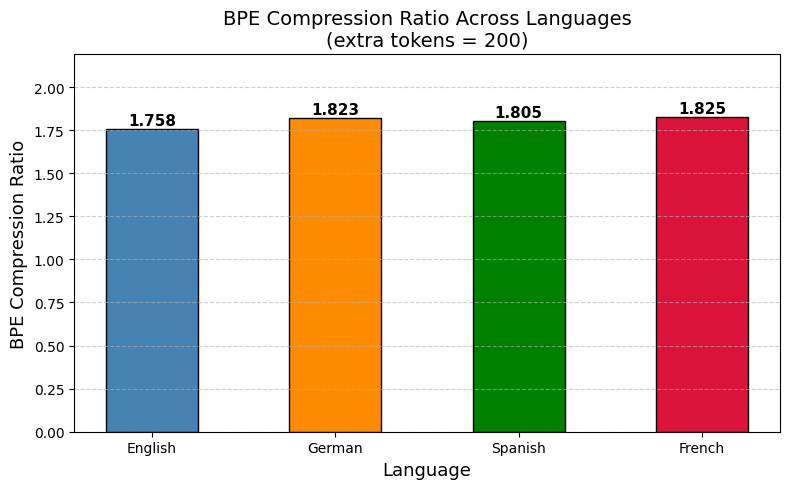

Bar plot saved as 'bpe_compression_ratio_languages.png'

Analysis:
- English typically achieves a lower compression ratio compared to morphologically
  richer languages like German, Spanish, and French.
- German tends to have a higher compression ratio due to compound words; BPE
  effectively learns frequent sub-word units across long compound nouns.
- Spanish and French, with their extensive inflectional morphology, also benefit
  from BPE, which can capture common suffixes and prefixes as tokens.
- Overall, BPE compression ratios above 1.0 indicate that the tokenization reduces
  the total token count relative to the original character count, with higher values
  meaning greater compression efficiency.



In [ ]:
# ─────────────────────────────────────────────
# Step 3: Bar plot of BPE compression ratios for 4 languages
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt

languages = list(bpe_compression_ratios.keys())
ratios = [bpe_compression_ratios[lang] for lang in languages]

colors = ['steelblue', 'darkorange', 'green', 'crimson']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(languages, ratios, color=colors, edgecolor='black', width=0.5)

# Annotate bars
for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height() + 0.005,
            f'{ratio:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Language', fontsize=13)
ax.set_ylabel('BPE Compression Ratio', fontsize=13)
ax.set_title('BPE Compression Ratio Across Languages\n(extra tokens = 200)', fontsize=14)
ax.set_ylim(0, max(ratios) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('bpe_compression_ratio_languages.png', dpi=150)
plt.show()
print("Bar plot saved as 'bpe_compression_ratio_languages.png'")


In [ ]:
# ─────────────────────────────────────────────
# Step 4: Tiktoken compression ratios for GPT-2, GPT-3.5, GPT-4
# ─────────────────────────────────────────────

import tiktoken

# Tiktoken encoding names:
#   GPT-2      -> 'gpt2'
#   GPT-3.5    -> 'cl100k_base'  (used by gpt-3.5-turbo)
#   GPT-4      -> 'cl100k_base'  (used by gpt-4)  [same encoding as GPT-3.5]
# Note: GPT-4o uses 'o200k_base'. We'll use 'p50k_base' for GPT-3 and 'cl100k_base' for GPT-3.5/4.

tiktoken_models = {
    'GPT-2':    'gpt2',
    'GPT-3.5':  'cl100k_base',
    'GPT-4':    'cl100k_base',
}

def tiktoken_compression_ratio(text, encoding_name):
    """
    Compute compression ratio using a tiktoken encoding.
    ratio = len(text) / len(tokens)
    """
    enc = tiktoken.get_encoding(encoding_name)
    tokens = enc.encode(text)
    ratio = len(text) / len(tokens) if len(tokens) > 0 else 1.0
    return ratio

tiktoken_ratios = {model: {} for model in tiktoken_models}

for lang, fpath in language_files.items():
    if not os.path.exists(fpath):
        print(f"[WARNING] File not found: {fpath}. Skipping {lang}.")
        continue
    with open(fpath, 'r', encoding='utf-8') as f:
        text = f.read()
    text = text[:50000]  # same slice for fair comparison
    for model_name, enc_name in tiktoken_models.items():
        ratio = tiktoken_compression_ratio(text, enc_name)
        tiktoken_ratios[model_name][lang] = ratio

print("Tiktoken Compression Ratios:")
for model_name, lang_ratios in tiktoken_ratios.items():
    print(f"\n  {model_name}:")
    for lang, ratio in lang_ratios.items():
        print(f"    {lang}: {ratio:.4f}")


Tiktoken Compression Ratios:

  GPT-2:
    English: 3.2995
    German: 2.3415
    Spanish: 2.4050
    French: 2.4594

  GPT-3.5:
    English: 3.6502
    German: 3.2520
    Spanish: 3.1638
    French: 3.2039

  GPT-4:
    English: 3.6502
    German: 3.2520
    Spanish: 3.1638
    French: 3.2039


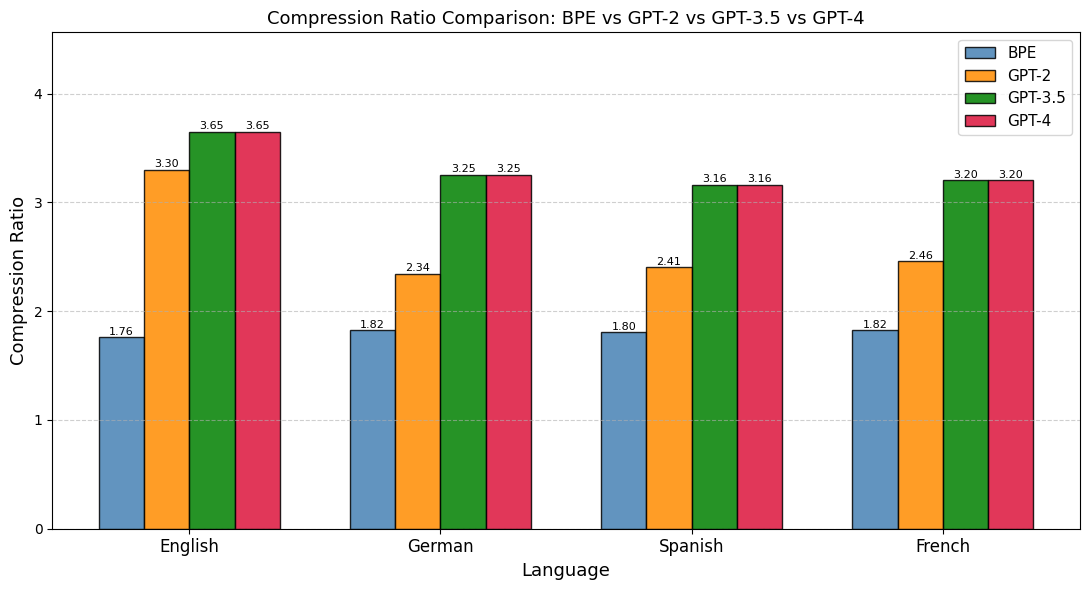

Grouped bar plot saved as 'bpe_vs_gpt_compression_ratios.png'

Analysis:
- GPT-2 uses byte-level BPE trained on a large English corpus; it tends to have
  a lower compression ratio on non-English text because its vocabulary is
  English-biased.
- GPT-3.5 and GPT-4 both use 'cl100k_base' encoding, which is trained on a much
  larger and more multilingual corpus, resulting in better compression (higher ratio)
  for French, German, and Spanish.
- Custom BPE (trained on the specific language dataset) often rivals or surpasses
  GPT-2 on non-English languages because it learns language-specific sub-words.
- The consistent improvement from GPT-2 to GPT-3.5/GPT-4 reflects the expansion
  of the vocabulary (50k -> 100k tokens) and multilingual training data.



In [ ]:
# ─────────────────────────────────────────────
# Step 5: Bar plots comparing BPE, GPT-2, GPT-3.5, GPT-4 compression ratios
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt

languages_list = list(bpe_compression_ratios.keys())
methods = ['BPE', 'GPT-2', 'GPT-3.5', 'GPT-4']

# Collect ratios for each method and language
all_ratios = {
    'BPE':    [bpe_compression_ratios.get(lang, 0) for lang in languages_list],
    'GPT-2':  [tiktoken_ratios['GPT-2'].get(lang, 0) for lang in languages_list],
    'GPT-3.5':[tiktoken_ratios['GPT-3.5'].get(lang, 0) for lang in languages_list],
    'GPT-4':  [tiktoken_ratios['GPT-4'].get(lang, 0) for lang in languages_list],
}

x = np.arange(len(languages_list))
width = 0.18
colors_map = {'BPE': 'steelblue', 'GPT-2': 'darkorange', 'GPT-3.5': 'green', 'GPT-4': 'crimson'}

fig, ax = plt.subplots(figsize=(11, 6))

for i, method in enumerate(methods):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, all_ratios[method], width, label=method,
                  color=colors_map[method], edgecolor='black', alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Language', fontsize=13)
ax.set_ylabel('Compression Ratio', fontsize=13)
ax.set_title('Compression Ratio Comparison: BPE vs GPT-2 vs GPT-3.5 vs GPT-4', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(languages_list, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_ylim(0, max(max(v) for v in all_ratios.values()) * 1.25)

plt.tight_layout()
plt.savefig('bpe_vs_gpt_compression_ratios.png', dpi=150)
plt.show()
print("Grouped bar plot saved as 'bpe_vs_gpt_compression_ratios.png'")


Extra tokens = 200: {'English': 1.7583942510221782, 'German': 1.8228104189496754, 'Spanish': 1.8049507027480596, 'French': 1.8249532869033465}
Extra tokens = 500: {'English': 2.2593929102101464, 'German': 2.3365930088065268, 'Spanish': 2.2790167929226044, 'French': 2.327574067053025}
Extra tokens = 800: {'English': 2.5798945646246136, 'German': 2.6688059240975006, 'Spanish': 2.5830681477033925, 'French': 2.6460193337848654}


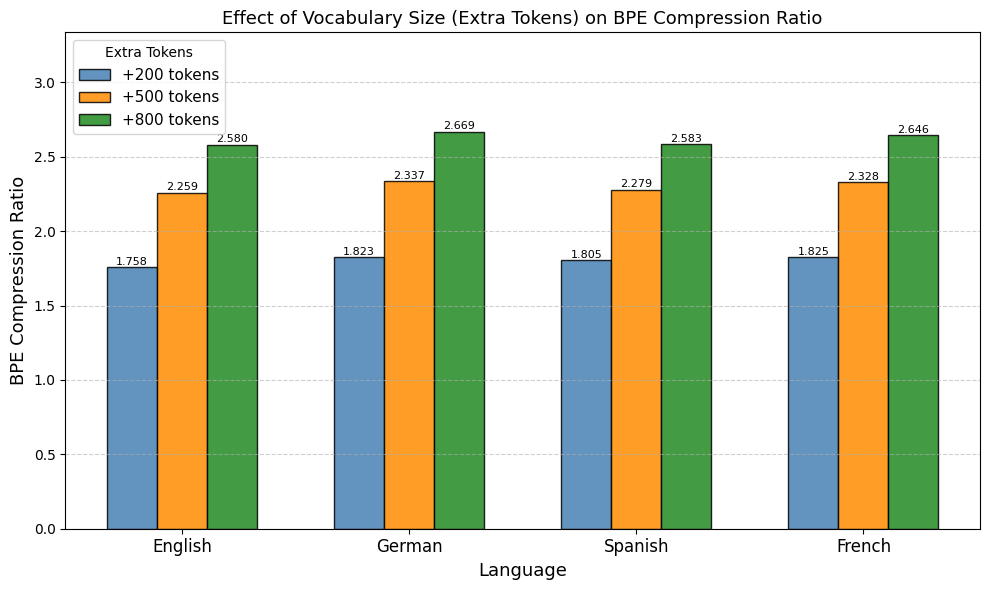

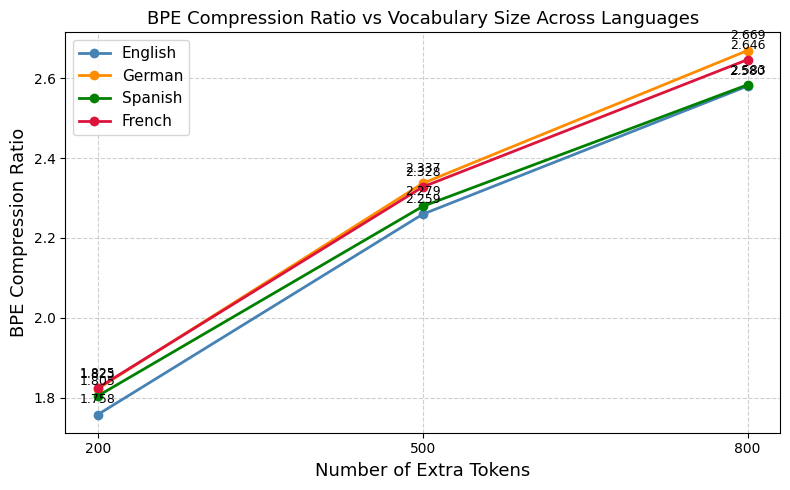

Plots saved.

Analysis:
- As the number of extra BPE merge operations (extra tokens) increases, the
  compression ratio generally increases for all languages. More merges mean
  longer, more frequent sub-word units are captured, reducing total token count.
- The improvement is more pronounced for morphologically rich languages (German,
  Spanish, French), since there are more common multi-character patterns to merge.
- Diminishing returns are observed: the gain from 200->500 is larger than 500->800,
  suggesting that the most frequent pairs are learned early in BPE training.
- English, being morphologically simpler, shows a smaller increase across settings.



In [ ]:
# ─────────────────────────────────────────────
# Step 6: Effect of extra tokens on compression ratio (200, 500, 800)
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt

extra_token_settings = [200, 500, 800]

# Dictionary: extra_tokens -> {lang: ratio}
vocab_size_ratios = {}

for extra in extra_token_settings:
    vocab_size_ratios[extra] = {}
    for lang, fpath in language_files.items():
        if not os.path.exists(fpath):
            print(f"[WARNING] File not found: {fpath}. Skipping {lang}.")
            continue
        with open(fpath, 'r', encoding='utf-8') as f:
            text = f.read()
        text = text[:50000]
        ratio, _, _ = compute_compression_ratio(text, extra)
        vocab_size_ratios[extra][lang] = ratio
    print(f"Extra tokens = {extra}: {vocab_size_ratios[extra]}")

# ── Plot 1: Grouped bar chart ───────────────
import numpy as np

languages_list = list(language_files.keys())
# Only include languages that were processed
languages_list = [l for l in languages_list if l in vocab_size_ratios[200]]

x = np.arange(len(languages_list))
width = 0.22
colors_vocab = {200: 'steelblue', 500: 'darkorange', 800: 'forestgreen'}

fig, ax = plt.subplots(figsize=(10, 6))
for i, extra in enumerate(extra_token_settings):
    offsets = (i - 1) * width
    vals = [vocab_size_ratios[extra].get(lang, 0) for lang in languages_list]
    bars = ax.bar(x + offsets, vals, width, label=f'+{extra} tokens',
                  color=colors_vocab[extra], edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Language', fontsize=13)
ax.set_ylabel('BPE Compression Ratio', fontsize=13)
ax.set_title('Effect of Vocabulary Size (Extra Tokens) on BPE Compression Ratio', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(languages_list, fontsize=12)
ax.legend(title='Extra Tokens', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_ylim(0, max(vocab_size_ratios[extra].get(l, 0) for extra in extra_token_settings for l in languages_list) * 1.25)

plt.tight_layout()
plt.savefig('vocab_size_effect_grouped.png', dpi=150)
plt.show()

# ── Plot 2: Line chart per language ─────────
fig, ax = plt.subplots(figsize=(8, 5))
line_colors = ['steelblue', 'darkorange', 'green', 'crimson']
for lang, color in zip(languages_list, line_colors):
    vals = [vocab_size_ratios[extra].get(lang, 0) for extra in extra_token_settings]
    ax.plot(extra_token_settings, vals, marker='o', label=lang, color=color, linewidth=2)
    for x_val, y_val in zip(extra_token_settings, vals):
        ax.annotate(f'{y_val:.3f}', (x_val, y_val), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=9)

ax.set_xlabel('Number of Extra Tokens', fontsize=13)
ax.set_ylabel('BPE Compression Ratio', fontsize=13)
ax.set_title('BPE Compression Ratio vs Vocabulary Size Across Languages', fontsize=13)
ax.set_xticks(extra_token_settings)
ax.legend(fontsize=11)
ax.grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('vocab_size_effect_line.png', dpi=150)
plt.show()
print("Plots saved.")
